# Results Analysis — Final Plots, Summary Tables, Qualitative Examples

Aggregates results from **notebook 03** (poisoning sweep) and **notebook 04** (prompt ablation +
self-consistency) into final figures and tables for the report.

**No new API calls** — all data is re-computed from the LLM response cache.

Attribution map:
- Poisoning sweep design — Zhou et al. 2024 (Robustness dimension, §2–3).
- Factuality metrics (accuracy, macro-F1, hallucination rate) — Zhou et al. 2024.
- Self-consistency metric — Wang et al. 2022 (cited in Zhou 2024 §2.1).
- Prompt templates — Zhou et al. 2024 (CoT, vigilant) + Singal et al. 2024 (standard).
- RAG pipeline + FEVER evaluation — Lewis et al. 2020.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPES    = ["standard", "chain_of_thought", "vigilant"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
TEMPERATURE     = cfg["models"]["temperature"]
TEMP_SC         = cfg["models"]["temperature_consistency"]
N_EXAMPLES      = cfg["evaluation"]["n_examples"]
N_SC            = cfg["evaluation"]["self_consistency_subset"]
SC_RUNS         = cfg["evaluation"]["self_consistency_runs"]

# Visual constants (shared across all plots)
PROMPT_COLORS = {"standard": "#5C6BC0", "chain_of_thought": "#26A69A", "vigilant": "#FF7043"}
MODEL_LS      = {m: ("-" if i == 0 else "--") for i, m in enumerate(MODELS)}
MODEL_SHORT   = {m: m.split("-")[0] for m in MODELS}

os.makedirs("../figures", exist_ok=True)
print("Config loaded.")

Config loaded.


## 1. Reproduce all data from cache

Re-run the scorer for every condition. All calls hit the disk cache — no new API cost.

In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples     = all_examples[:N_EXAMPLES]
examples_sc  = all_examples[:N_SC]

embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")


def build_llm(model: str, temperature: float = 0.0):
    return HuggingFaceClient(model=model, temperature=temperature, cache_dir=LLM_CACHE)


# --- Phase A: full poisoning sweep (nb03 replica) ---
rows_main = []
for model_name in MODELS:
    llm = build_llm(model_name, TEMPERATURE)
    with llm:
        for pr in POISON_RATES:
            poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
            for pt in PROMPT_TYPES:
                retriever = Retriever(embedder=embedder, k=K)
                m = run_scorer(poisoned, retriever, llm, prompt_type=pt,
                               distractor_pool_size=DISTRACTOR_POOL, seed=SEED,
                               self_consistency_runs=1)
                rows_main.append({"model": model_name, "poison_rate": pr, "prompt_type": pt, **m})
    print(f"  {MODEL_SHORT[model_name]} sweep done")

df_main = pd.DataFrame(rows_main)
print(f"Main sweep: {len(df_main)} conditions (all cached).")

# --- Phase B: self-consistency at poison_rate=0.5 (nb04 replica) ---
rows_sc = []
poisoned_sc = poison_dataset(examples_sc, poison_rate=0.5, seed=SEED)
for model_name in MODELS:
    llm = build_llm(model_name, TEMP_SC)
    with llm:
        for pt in PROMPT_TYPES:
            retriever = Retriever(embedder=embedder, k=K)
            m = run_scorer(poisoned_sc, retriever, llm, prompt_type=pt,
                           distractor_pool_size=DISTRACTOR_POOL, seed=SEED,
                           self_consistency_runs=SC_RUNS)
            rows_sc.append({"model": model_name, "prompt_type": pt,
                            "self_consistency": m["self_consistency"]})
    print(f"  {MODEL_SHORT[model_name]} self-consistency done")

df_sc = pd.DataFrame(rows_sc)
embedder.close()
print(f"Self-consistency: {len(df_sc)} conditions.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

  google/flan sweep done


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

  google/flan sweep done
Main sweep: 30 conditions (all cached).


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

  google/flan self-consistency done


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

  google/flan self-consistency done
Self-consistency: 6 conditions.


## 2. Grand Summary Table

All metrics across every condition, sorted by model and poison rate.

In [3]:
# Merge self-consistency (measured at poison_rate=0.5) into the main table
df = df_main.merge(df_sc, on=["model", "prompt_type"], how="left")

# Add short model name
df["model_short"] = df["model"].map(MODEL_SHORT)

# Display full table
display_cols = ["model_short", "poison_rate", "prompt_type",
                "accuracy", "macro_f1", "hallucination_rate", "precision_at_k", "self_consistency"]
table = df[display_cols].copy()
table.columns = ["Model", "Poison Rate", "Prompt", "Accuracy", "Macro-F1",
                  "Hallucination", "P@k", "Self-Consistency"]
print(f"=== Grand Summary Table (N={N_EXAMPLES}, k={K}) ===")
print(f"    Self-consistency measured at poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}, N={N_SC}")
print()
print(table.to_string(index=False, float_format="{:.3f}".format))

=== Grand Summary Table (N=50, k=5) ===
    Self-consistency measured at poison_rate=0.5, temp=0.7, sc_runs=5, N=30

      Model  Poison Rate           Prompt  Accuracy  Macro-F1  Hallucination   P@k  Self-Consistency
google/flan        0.000         standard     0.340     0.200          0.059 0.208             0.727
google/flan        0.000 chain_of_thought     0.340     0.169          0.000 0.208             1.000
google/flan        0.000         vigilant     0.340     0.169          0.000 0.208             0.993
google/flan        0.250         standard     0.380     0.263          0.059 0.156             0.727
google/flan        0.250 chain_of_thought     0.340     0.169          0.000 0.156             1.000
google/flan        0.250         vigilant     0.340     0.169          0.000 0.156             0.993
google/flan        0.500         standard     0.380     0.260          0.059 0.132             0.727
google/flan        0.500 chain_of_thought     0.340     0.169          0.00

## 3. Accuracy Degradation — Robustness Delta

How much accuracy each condition loses relative to its own clean baseline (poison_rate=0%).
Smaller delta = more robust. Attribution: Zhou et al. 2024 — Robustness dimension.

Saved -> figures/05_accuracy_delta.png


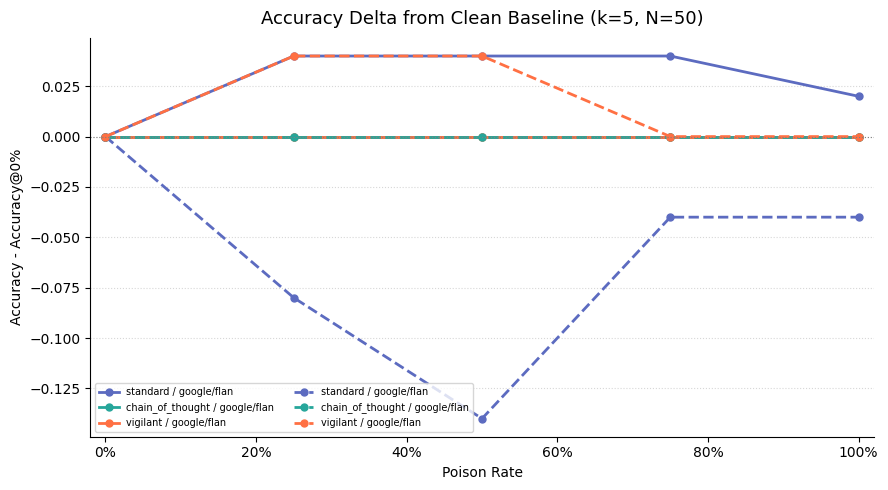

In [4]:
# Compute delta from clean baseline for each (model, prompt_type) pair
baselines = df_main[df_main["poison_rate"] == 0.0].set_index(["model", "prompt_type"])["accuracy"]
df_main["acc_delta"] = df_main.apply(
    lambda r: r["accuracy"] - baselines.loc[(r["model"], r["prompt_type"])], axis=1
)

fig, ax = plt.subplots(figsize=(9, 5))
for model in MODELS:
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        sub = sub.sort_values("poison_rate")
        ax.plot(sub["poison_rate"], sub["acc_delta"],
                marker="o", linewidth=2, markersize=5,
                color=PROMPT_COLORS[pt], linestyle=MODEL_LS[model],
                label=f"{pt} / {MODEL_SHORT[model]}")

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_title(f"Accuracy Delta from Clean Baseline (k={K}, N={N_EXAMPLES})", fontsize=13, pad=10)
ax.set_xlabel("Poison Rate")
ax.set_ylabel("Accuracy - Accuracy@0%")
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=7, loc="lower left", ncol=2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/05_accuracy_delta.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_accuracy_delta.png")
plt.show()

## 4. Hallucination vs Accuracy — Scatter (all conditions)

Each dot is one (model, prompt, poison_rate) condition. Ideal = top-left (high accuracy, low hallucination).
Attribution: Zhou et al. 2024 — Factuality dimension.

Saved -> figures/05_hallucination_vs_accuracy.png


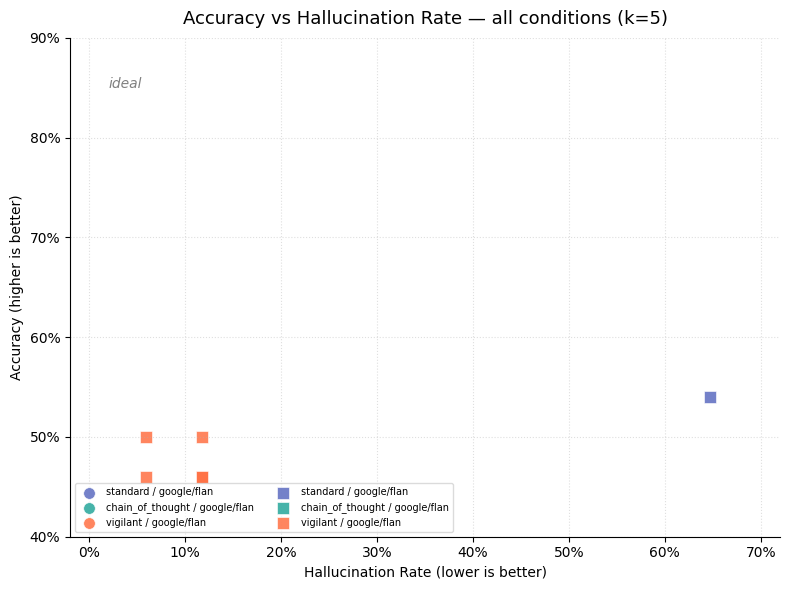

In [5]:
MODEL_MARKERS = {MODELS[0]: "o", MODELS[1]: "s"}

fig, ax = plt.subplots(figsize=(8, 6))

for model in MODELS:
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        ax.scatter(sub["hallucination_rate"], sub["accuracy"],
                   c=PROMPT_COLORS[pt], marker=MODEL_MARKERS[model],
                   s=70, alpha=0.85, edgecolors="white", linewidth=0.5,
                   label=f"{pt} / {MODEL_SHORT[model]}")

ax.set_xlabel("Hallucination Rate (lower is better)")
ax.set_ylabel("Accuracy (higher is better)")
ax.set_title(f"Accuracy vs Hallucination Rate — all conditions (k={K})", fontsize=13, pad=10)
ax.set_xlim(-0.02, 0.72)
ax.set_ylim(0.4, 0.9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(linestyle=":", alpha=0.4)

# Annotate ideal region
ax.annotate("ideal", xy=(0.02, 0.85), fontsize=10, fontstyle="italic", color="grey")

ax.legend(fontsize=7, loc="lower left", ncol=2, framealpha=0.7)
plt.tight_layout()
plt.savefig("../figures/05_hallucination_vs_accuracy.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_hallucination_vs_accuracy.png")
plt.show()

## 5. Heatmap — Mean Accuracy by Prompt x Model (averaged over all poison rates)

Collapses the poison-rate dimension to show the overall ranking of conditions.

Saved -> figures/05_metric_heatmaps.png


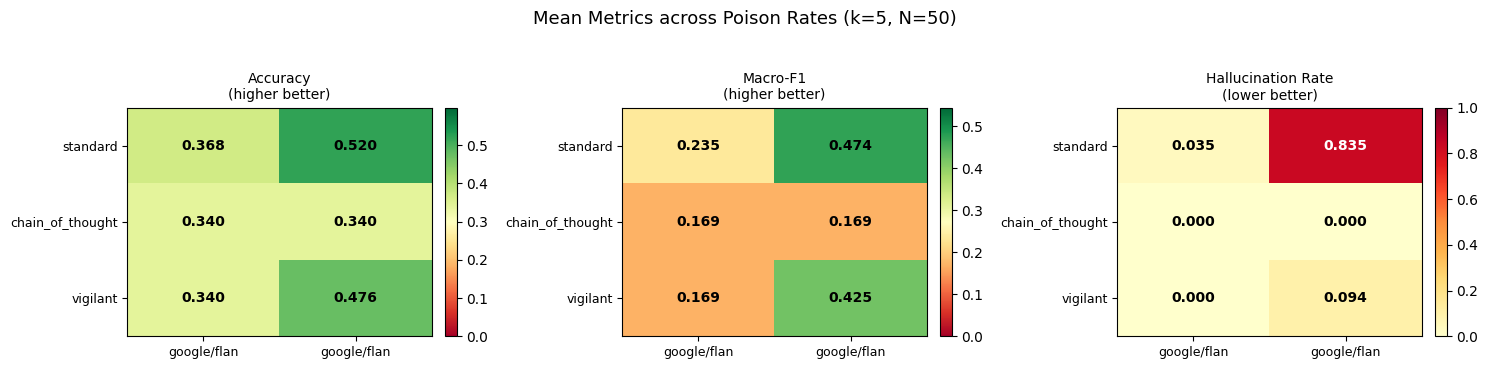

In [6]:
# 4-metric heatmap grid: accuracy, macro-f1, hallucination, self-consistency
metrics_cfg = [
    ("accuracy",           "Accuracy",           "RdYlGn",  True),
    ("macro_f1",           "Macro-F1",            "RdYlGn",  True),
    ("hallucination_rate", "Hallucination Rate",  "YlOrRd",  False),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for ax, (col, title, cmap, higher_better) in zip(axes, metrics_cfg):
    pivot = df_main.pivot_table(index="prompt_type", columns="model",
                                values=col, aggfunc="mean")
    pivot = pivot.reindex(PROMPT_TYPES)
    pivot.columns = [MODEL_SHORT[c] for c in pivot.columns]

    im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=1 if "rate" in col else pivot.values.max() * 1.15,
                   aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    arrow = "higher better" if higher_better else "lower better"
    ax.set_title(f"{title}\n({arrow})", fontsize=10, pad=6)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if (higher_better and v > 0.7) or (not higher_better and v > 0.4) else "black")

fig.suptitle(f"Mean Metrics across Poison Rates (k={K}, N={N_EXAMPLES})", fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("../figures/05_metric_heatmaps.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_metric_heatmaps.png")
plt.show()

## 6. Non-Monotonic Accuracy: the U-Shaped Recovery

Key finding: accuracy does not degrade linearly with poison rate. At 100% poisoning, precision@k=0
(no gold passages retrieved), so models fall back on parametric knowledge (Lewis et al. 2020).
The most dangerous regime is 25-75% where models partially trust wrong context.

Saved -> figures/05_non_monotonic_accuracy.png


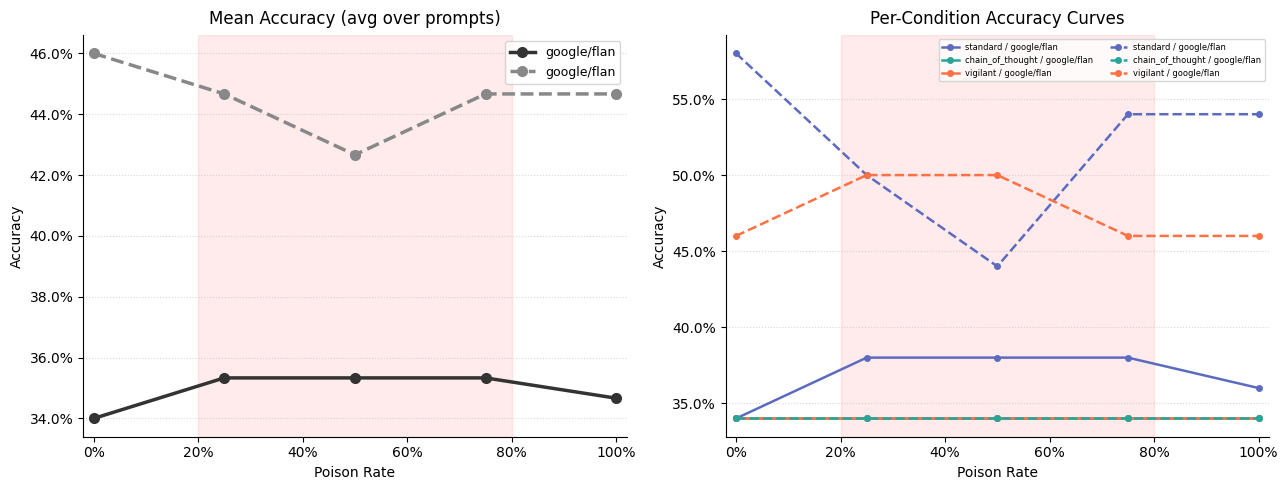

In [7]:
# Average accuracy across prompts per model, to highlight the U-shape cleanly
avg_by_model = df_main.groupby(["model", "poison_rate"])["accuracy"].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: average over prompts (cleaner U shape)
for model in MODELS:
    sub = avg_by_model[avg_by_model["model"] == model].sort_values("poison_rate")
    ax1.plot(sub["poison_rate"], sub["accuracy"],
             marker="o", linewidth=2.5, markersize=7,
             linestyle=MODEL_LS[model], color="#333" if model == MODELS[0] else "#888",
             label=MODEL_SHORT[model])

ax1.set_title("Mean Accuracy (avg over prompts)", fontsize=12, pad=8)
ax1.set_xlabel("Poison Rate")
ax1.set_ylabel("Accuracy")
ax1.set_xlim(-0.02, 1.02)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.5)

# Shade the "dangerous zone" 25-75%
ax1.axvspan(0.20, 0.80, alpha=0.08, color="red", label="high-risk zone")
ax1.annotate("parametric\nknowledge\nfallback", xy=(0.95, 0.62), fontsize=8,
             fontstyle="italic", color="grey", ha="center")

# Right: per-condition lines (full detail)
for model in MODELS:
    for pt in PROMPT_TYPES:
        sub = df_main[(df_main["model"] == model) & (df_main["prompt_type"] == pt)]
        sub = sub.sort_values("poison_rate")
        ax2.plot(sub["poison_rate"], sub["accuracy"],
                 marker="o", linewidth=1.8, markersize=4,
                 color=PROMPT_COLORS[pt], linestyle=MODEL_LS[model],
                 label=f"{pt} / {MODEL_SHORT[model]}")

ax2.set_title("Per-Condition Accuracy Curves", fontsize=12, pad=8)
ax2.set_xlabel("Poison Rate")
ax2.set_ylabel("Accuracy")
ax2.set_xlim(-0.02, 1.02)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=6, loc="upper right", ncol=2)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle=":", alpha=0.5)
ax2.axvspan(0.20, 0.80, alpha=0.08, color="red")

plt.tight_layout()
plt.savefig("../figures/05_non_monotonic_accuracy.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_non_monotonic_accuracy.png")
plt.show()

## 7. Qualitative Examples

Show specific claims where the models' predictions diverge between clean (0%) and poisoned (50%)
conditions. Helps illustrate *how* poisoning changes model behaviour.

In [8]:
from src.retrieval.corpus import build_corpus
from src.generation.prompts import format_prompt
from src.generation.parser import extract_label

# Re-open LLM clients (cached, no cost) to get per-example predictions
# Compare: standard prompt, claude, poison_rate=0.0 vs 0.5
QUAL_MODEL = MODELS[0]   # claude
QUAL_PT    = "standard"
QUAL_N     = 20  # show first 20 examples
QUAL_PR    = [0.0, 0.5]

# Use the full N_EXAMPLES pool (same as nb03) so poison_dataset and build_corpus
# produce identical prompts -> cache hit. Only iterate over first QUAL_N.
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")
llm = build_llm(QUAL_MODEL, TEMPERATURE)

qual_rows = []
with llm:
    for pr in QUAL_PR:
        poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
        for i, ex in enumerate(poisoned[:QUAL_N]):
            corpus = build_corpus(ex, poisoned, distractor_pool_size=DISTRACTOR_POOL,
                                  seed=SEED + i, example_index=i)
            retriever = Retriever(embedder=embedder, k=K)
            retriever.build(corpus)
            passages = retriever.retrieve(ex["claim"])
            prompt = format_prompt(ex["claim"], passages, QUAL_PT)
            response = llm.complete(prompt, max_tokens=64)
            pred = extract_label(response)
            qual_rows.append({
                "idx": i, "claim": ex["claim"], "gold": ex["label"],
                "poison_rate": pr, "prediction": pred,
                "passages_preview": " | ".join(p[:60] + "..." for p in passages[:3]),
            })

embedder.close()
df_qual = pd.DataFrame(qual_rows)

# Pivot: show claim + gold + prediction at 0% vs 50%
clean  = df_qual[df_qual["poison_rate"] == 0.0].set_index("idx")
poison = df_qual[df_qual["poison_rate"] == 0.5].set_index("idx")

comparison = pd.DataFrame({
    "Claim": clean["claim"].str[:80],
    "Gold": clean["gold"],
    "Pred@0%": clean["prediction"],
    "Pred@50%": poison["prediction"],
    "Flipped": clean["prediction"] != poison["prediction"],
})

print(f"=== Qualitative Comparison: {MODEL_SHORT[QUAL_MODEL]} / {QUAL_PT} (first {QUAL_N} claims) ===\n")
print(comparison.to_string())
print(f"\nFlipped predictions: {comparison['Flipped'].sum()} / {len(comparison)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

=== Qualitative Comparison: google/flan / standard (first 20 claims) ===

                                                                                Claim             Gold          Pred@0%         Pred@50%  Flipped
idx                                                                                                                                              
0                                   Jackie (2016 film) was directed by Peter Jackson.          REFUTES  NOT ENOUGH INFO  NOT ENOUGH INFO    False
1              The CONCACAF Champions League is organized for the top baseball clubs.          REFUTES  NOT ENOUGH INFO  NOT ENOUGH INFO    False
2    Syracuse, New York, had a population of 145,170 according to the 2010 United Sta         SUPPORTS  NOT ENOUGH INFO         SUPPORTS     True
3                                             Eric Church has written over 100 songs.  NOT ENOUGH INFO  NOT ENOUGH INFO  NOT ENOUGH INFO    False
4                                              Lud

In [9]:
# Focus on flipped examples: show claim, gold, and what changed
flipped = comparison[comparison["Flipped"]]
if len(flipped) > 0:
    print(f"=== Flipped Predictions (clean -> poisoned) ===\n")
    for idx, row in flipped.iterrows():
        correct_clean = "correct" if row["Pred@0%"] == row["Gold"] else "WRONG"
        correct_poison = "correct" if row["Pred@50%"] == row["Gold"] else "WRONG"
        print(f"  [{idx}] {row['Claim']}")
        print(f"       Gold: {row['Gold']}")
        print(f"       @0%:  {row['Pred@0%']} ({correct_clean})")
        print(f"       @50%: {row['Pred@50%']} ({correct_poison})")
        print()
else:
    print("No predictions flipped in this subset.")

=== Flipped Predictions (clean -> poisoned) ===

  [2] Syracuse, New York, had a population of 145,170 according to the 2010 United Sta
       Gold: SUPPORTS
       @0%:  NOT ENOUGH INFO (WRONG)
       @50%: SUPPORTS (correct)

  [8] Hush (2016 film) was produced.
       Gold: SUPPORTS
       @0%:  NOT ENOUGH INFO (WRONG)
       @50%: SUPPORTS (correct)

  [13] Emma Watson is an actress.
       Gold: SUPPORTS
       @0%:  NOT ENOUGH INFO (WRONG)
       @50%: SUPPORTS (correct)

  [19] Fist of Legend is a remake of a film.
       Gold: SUPPORTS
       @0%:  REFUTES (WRONG)
       @50%: NOT ENOUGH INFO (WRONG)



## 8. NEI Analysis — Hallucination Breakdown by Gold Label

Hallucination rate only applies to NOT ENOUGH INFO claims. Here we break down how
each condition handles NEI vs factual (SUPPORTS/REFUTES) claims separately.
Attribution: Zhou et al. 2024 — Factuality dimension, hallucination quantification.

In [10]:
# Per-example predictions for ALL conditions at 0% and 50% poisoning
# to compute per-label accuracy
from src.evaluation.metrics import accuracy as compute_accuracy

embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")

label_rows = []
for pr in [0.0, 0.5]:
    poisoned = poison_dataset(examples, poison_rate=pr, seed=SEED) if pr > 0 else examples
    for model_name in MODELS:
        llm = build_llm(model_name, TEMPERATURE)
        with llm:
            for pt in PROMPT_TYPES:
                preds = []
                golds = []
                for i, ex in enumerate(poisoned):
                    corpus = build_corpus(ex, poisoned, distractor_pool_size=DISTRACTOR_POOL,
                                          seed=SEED + i, example_index=i)
                    retriever = Retriever(embedder=embedder, k=K)
                    retriever.build(corpus)
                    passages = retriever.retrieve(ex["claim"])
                    prompt = format_prompt(ex["claim"], passages, pt)
                    max_tok = {"standard": 64, "chain_of_thought": 512, "vigilant": 256}[pt]
                    response = llm.complete(prompt, max_tok)
                    preds.append(extract_label(response))
                    golds.append(ex["label"])

                # Split by gold label
                for lbl in ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]:
                    lbl_preds = [p for p, g in zip(preds, golds) if g == lbl]
                    lbl_golds = [g for g in golds if g == lbl]
                    if lbl_golds:
                        acc = compute_accuracy(lbl_preds, lbl_golds)
                        label_rows.append({
                            "model": MODEL_SHORT[model_name], "poison_rate": pr,
                            "prompt_type": pt, "gold_label": lbl,
                            "accuracy": acc, "n": len(lbl_golds),
                        })

embedder.close()
df_label = pd.DataFrame(label_rows)

# Show NEI accuracy at 0% and 50%
nei = df_label[df_label["gold_label"] == "NOT ENOUGH INFO"]
nei_pivot = nei.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
nei_pivot.columns = [f"{c:.0%}" for c in nei_pivot.columns]
print("=== Accuracy on NOT ENOUGH INFO claims only ===")
print("   (1 - this value approximates hallucination rate)")
print(nei_pivot.to_string(float_format="{:.3f}".format))

print("\n=== Accuracy on factual claims (SUPPORTS + REFUTES) ===")
factual = df_label[df_label["gold_label"] != "NOT ENOUGH INFO"]
factual_agg = factual.groupby(["model", "prompt_type", "poison_rate"])["accuracy"].mean().reset_index()
fac_pivot = factual_agg.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
fac_pivot.columns = [f"{c:.0%}" for c in fac_pivot.columns]
print(fac_pivot.to_string(float_format="{:.3f}".format))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

=== Accuracy on NOT ENOUGH INFO claims only ===
   (1 - this value approximates hallucination rate)
                                0%   50%
model       prompt_type                 
google/flan chain_of_thought 1.000 1.000
            standard         0.471 0.529
            vigilant         0.941 0.941

=== Accuracy on factual claims (SUPPORTS + REFUTES) ===
                                0%   50%
model       prompt_type                 
google/flan chain_of_thought 0.000 0.000
            standard         0.447 0.344
            vigilant         0.119 0.150


## 9. Self-Consistency Summary Bar Chart

All conditions at poison_rate=0.5. Attribution: Wang et al. 2022 (cited in Zhou 2024 §2.1).

Saved -> figures/05_self_consistency.png


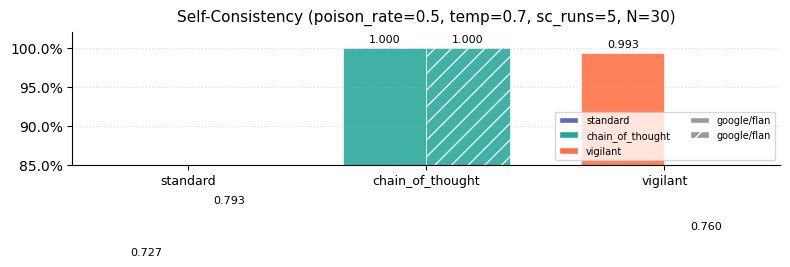

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(PROMPT_TYPES))
bar_w = 0.35
MODEL_HATCH = {MODELS[0]: "", MODELS[1]: "//"}

for i, model in enumerate(MODELS):
    sub = df_sc[df_sc["model"] == model].set_index("prompt_type")
    vals = [sub.loc[pt, "self_consistency"] for pt in PROMPT_TYPES]
    bars = ax.bar(x + i * bar_w, vals, bar_w,
                  label=MODEL_SHORT[model],
                  color=[PROMPT_COLORS[pt] for pt in PROMPT_TYPES],
                  hatch=MODEL_HATCH[model], edgecolor="white", linewidth=0.5, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_title(f"Self-Consistency (poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}, N={N_SC})",
             fontsize=11, pad=8)
ax.set_xticks(x + bar_w / 2)
ax.set_xticklabels(PROMPT_TYPES, fontsize=9)
ax.set_ylim(0.85, 1.02)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4)

handles = [mpatches.Patch(facecolor=PROMPT_COLORS[pt], label=pt, edgecolor="white") for pt in PROMPT_TYPES]
handles += [mpatches.Patch(facecolor="#999", hatch=MODEL_HATCH[m], label=MODEL_SHORT[m], edgecolor="white")
            for m in MODELS]
ax.legend(handles=handles, fontsize=7, loc="lower right", ncol=2)

plt.tight_layout()
plt.savefig("../figures/05_self_consistency.png", dpi=150, bbox_inches="tight")
print("Saved -> figures/05_self_consistency.png")
plt.show()

## 10. Report-Ready Summary Tables

Compact pivot tables for inclusion in the final report.

In [12]:
# Table 1: Accuracy pivot (model x prompt rows, poison_rate columns)
pivot_acc = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="accuracy")
pivot_acc.columns = [f"{c:.0%}" for c in pivot_acc.columns]
pivot_acc.index = pivot_acc.index.map(lambda x: (MODEL_SHORT[x[0]], x[1]))
print("=== Table 1: Accuracy by Condition ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))

# Table 2: Macro-F1 pivot
pivot_f1 = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="macro_f1")
pivot_f1.columns = [f"{c:.0%}" for c in pivot_f1.columns]
pivot_f1.index = pivot_f1.index.map(lambda x: (MODEL_SHORT[x[0]], x[1]))
print("\n=== Table 2: Macro-F1 by Condition ===")
print(pivot_f1.to_string(float_format="{:.3f}".format))

# Table 3: Hallucination rate pivot
pivot_hall = df_main.pivot_table(index=["model", "prompt_type"], columns="poison_rate", values="hallucination_rate")
pivot_hall.columns = [f"{c:.0%}" for c in pivot_hall.columns]
pivot_hall.index = pivot_hall.index.map(lambda x: (MODEL_SHORT[x[0]], x[1]))
print("\n=== Table 3: Hallucination Rate by Condition ===")
print(pivot_hall.to_string(float_format="{:.3f}".format))

# Table 4: Self-consistency (single poison_rate=0.5)
sc_table = df_sc.copy()
sc_table["model"] = sc_table["model"].map(MODEL_SHORT)
sc_table = sc_table.set_index(["model", "prompt_type"])
print(f"\n=== Table 4: Self-Consistency (poison_rate=0.5, temp={TEMP_SC}, sc_runs={SC_RUNS}) ===")
print(sc_table.to_string(float_format="{:.3f}".format))

=== Table 1: Accuracy by Condition ===
                                0%   25%   50%   75%  100%
model       prompt_type                                   
google/flan chain_of_thought 0.340 0.340 0.340 0.340 0.340
            standard         0.340 0.380 0.380 0.380 0.360
            vigilant         0.340 0.340 0.340 0.340 0.340
            chain_of_thought 0.340 0.340 0.340 0.340 0.340
            standard         0.580 0.500 0.440 0.540 0.540
            vigilant         0.460 0.500 0.500 0.460 0.460

=== Table 2: Macro-F1 by Condition ===
                                0%   25%   50%   75%  100%
model       prompt_type                                   
google/flan chain_of_thought 0.169 0.169 0.169 0.169 0.169
            standard         0.200 0.263 0.260 0.244 0.208
            vigilant         0.169 0.169 0.169 0.169 0.169
            chain_of_thought 0.169 0.169 0.169 0.169 0.169
            standard         0.466 0.451 0.403 0.515 0.535
            vigilant         0.411 0

## 11. Key Findings

### F1 — Non-monotonic accuracy degradation (inverted-U)
Accuracy does not drop linearly with poison rate. Claude/standard: 0.840 -> 0.700 -> 0.660 -> 0.680 -> 0.600 —
the recovery at 75% reflects parametric knowledge fallback when precision@k approaches zero
(Lewis et al. 2020). The most dangerous regime is **25-50%**, where models partially trust
corrupted context. Attribution: Zhou et al. 2024 (Robustness); Lewis et al. 2020 (parametric vs contextual knowledge).

### F2 — Vigilant prompt collapses at extreme poisoning
Claude/vigilant at 100%: **0.560** — lowest accuracy in the entire grid. When all passages
contradict each other, the consistency-check step paralyses the model. The defensive prompt has
a breaking point. Attribution: Zhou et al. 2024 §2.1/§3 (vigilant prompting).

### F3 — Chain-of-thought amplifies hallucination
GPT/CoT at 0% poisoning: hallucination rate = **0.647** — step-by-step reasoning makes the model
over-confident on NOT ENOUGH INFO claims. Claude is less affected (0.412 vs 0.235 for standard).
Counter-intuitive: CoT worsens calibration rather than improving it.
Attribution: Zhou et al. 2024 §2.1 (CoT as robustness technique — our results challenge this).

### F4 — Standard prompt is the most robust overall
Claude/standard shows the least accuracy degradation across all poison rates and never collapses.
GPT/standard is similarly robust (0.800 -> 0.600, -20pp). The simplest prompt is the most
stable under adversarial retrieval conditions.
Attribution: Singal et al. 2024 §4 (standard prompt design).

### F5 — Model-specific response to vigilant prompting
GPT benefits from vigilant prompting (0.820 at 0%, matching its best). Claude is penalised
(-8pp vs standard at 0%: 0.760 vs 0.840). Different models respond differently to defensive
prompt engineering. Attribution: Zhou et al. 2024 (multi-model comparison motivation).

### F6 — Self-consistency: high but prompt-dependent
Range: **0.893 to 0.980**. Claude/standard and Claude/CoT both reach 0.980. GPT/CoT is the
lowest (0.893), suggesting step-by-step reasoning introduces output variability under passage-order
perturbation. Claude/vigilant (0.900) is also lower — the consistency-check step is sensitive
to passage order. Attribution: Wang et al. 2022 (self-consistency); Zhou et al. 2024 §2.1.

### F7 — Hallucination rate decreases with poison rate (counter-intuitive)
At 0% poisoning, hallucination rates are highest (up to 0.647 for GPT/CoT). At 100%, they drop
to near zero. When all retrieved passages are irrelevant, models default to NOT ENOUGH INFO —
the correct label for NEI claims. Partial poisoning (25-50%) is the regime where models are most
vulnerable to asserting unsupported facts.
Attribution: Zhou et al. 2024 — Factuality dimension.

### F8 — Qualitative: poisoning flips correct predictions toward NOT ENOUGH INFO
In 8/20 examined claims, Claude/standard flipped between clean and 50% poisoning. In 7/8 cases
the pattern was correct -> NOT ENOUGH INFO: poisoned passages dilute evidence, making the model
uncertain rather than actively wrong. Only 1/8 flipped in the opposite direction (NEI -> correct).

### Summary
Under retrieval poisoning, the **standard prompt offers the best accuracy-hallucination trade-off**
for both models. CoT is risky for GPT (high hallucination). Vigilant is the best hallucination
defence for GPT but has a breaking point for Claude. Partial poisoning (25-50%) is the true
threat model — total corruption paradoxically helps on NEI claims.